In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import matplotlib.pyplot as plot
import seaborn as sns
import re

from glob import glob

import librosa
import librosa.display
import IPython.display as ipd

from itertools import cycle
import soundfile


color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_cycle = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])

### experimental personal imports
helping map points with tkinter using twodpm (two dimensional)
help map 3d coordinates using threedpm (three dimensional)


In [2]:
import src.tkinter_point_mapper as td
from importlib import reload
reload(td)

<module 'src.tkinter_point_mapper' from 'c:\\Users\\rudra\\Desktop\\work\\wave_to_svg\\src\\tkinter_point_mapper.py'>

In [3]:
audio_files = glob("music/*.mp3")
other_files = glob("music/vanisher_horizon_scraper/*.wav")
audio_files.extend(other_files)



In [4]:
working_file = audio_files[3]
ipd.Audio(working_file)
#y, sr = librosa.load(working_file)
#soundfile.write('music/keep_a_smile_454_slowed.wav', y, int(sr//2), format='WAV')

In [ ]:
y, sr = librosa.load(working_file)
print(f'y: {y[:10]}')
print(f'shape y: {y.shape}')
print(f'sr: {sr}')
# in one second of audio there are {sr} samples
# length of audio in seconds = len(y) / sr
# to get a any stretch of time, second*sr : (second+duration)*sr
d = librosa.amplitude_to_db(y)

In [ ]:
#Displaying the audio (to find high and low deciblel)
pd.Series(d).plot(figsize=(10, 5),
                  lw=1,
                  title='Raw Audio display',
                 color=color_pal[0])
plt.show()

In [ ]:
y, _ = librosa.effects.trim(y, top_db=20)

# Isolating vocals with librosa

### Loading file

In [6]:
all_data, sr = librosa.load('music/ROBBERY - asap rocky doechii.mp3')
#all_data, sr = librosa.load('music/new david bowie.mp3')


# And compute the spectrogram magnitude and phase
S_full, phase = librosa.magphase(librosa.stft(all_data))

# Play back a 5-second excerpt with vocals
ipd.Audio(data=all_data[10*sr:15*sr], rate=sr)

### Change these values to adjust vocal / background level

margin_i : background 

margin_v : foreground

power : 

In [13]:
# We can also use a margin to reduce bleed between the vocals and instrumentation masks.
# Note: the margins need not be equal for foreground and background separation
margin_i, margin_v = 20, 2
power = 4

### Isolate vocals

credits: https://librosa.org/doc/0.9.2/auto_examples/plot_vocal_separation.html

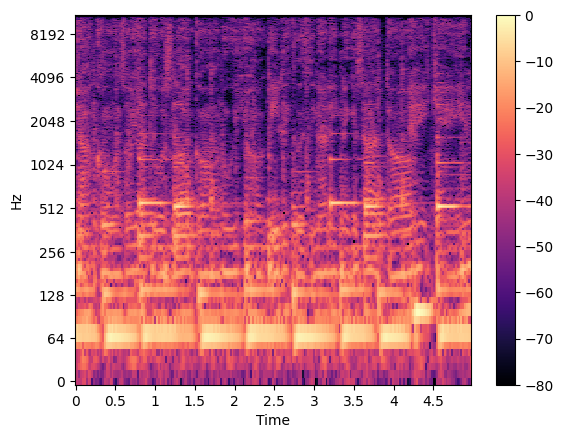

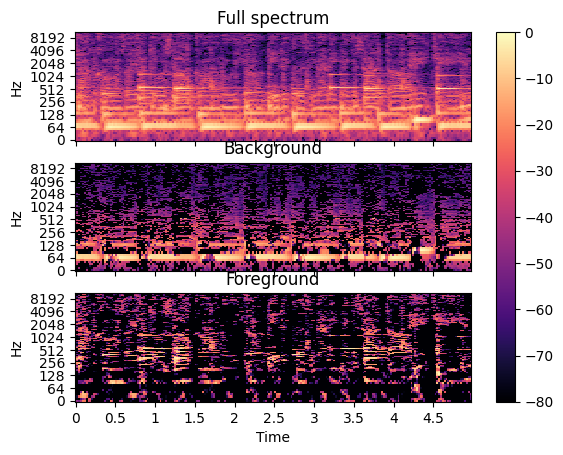

In [15]:
#plotting 
idx = slice(*librosa.time_to_frames([10, 15], sr=sr))
fig, ax = plt.subplots()
img = librosa.display.specshow(librosa.amplitude_to_db(S_full[:, idx], ref=np.max),
                         y_axis='log', x_axis='time', sr=sr, ax=ax)
fig.colorbar(img, ax=ax)


S_filter = librosa.decompose.nn_filter(S_full,
                                       aggregate=np.median,
                                       metric='cosine',
                                       width=int(librosa.time_to_frames(2, sr=sr)))

# The output of the filter shouldn't be greater than the input
# if we assume signals are additive.  Taking the pointwise minimum
# with the input spectrum forces this.
S_filter = np.minimum(S_full, S_filter)



mask_i = librosa.util.softmask(S_filter,
                               margin_i * (S_full - S_filter),
                               power=power)

mask_v = librosa.util.softmask(S_full - S_filter,
                               margin_v * S_filter,
                               power=power)

# Once we have the masks, simply multiply them with the input spectrum
# to separate the components

S_foreground = mask_v * S_full
S_background = mask_i * S_full

#plotting seperate
fig, ax = plt.subplots(nrows=3, sharex=True, sharey=True)
img = librosa.display.specshow(librosa.amplitude_to_db(S_full[:, idx], ref=np.max),
                         y_axis='log', x_axis='time', sr=sr, ax=ax[0])
ax[0].set(title='Full spectrum')
ax[0].label_outer()

librosa.display.specshow(librosa.amplitude_to_db(S_background[:, idx], ref=np.max),
                         y_axis='log', x_axis='time', sr=sr, ax=ax[1])
ax[1].set(title='Background')
ax[1].label_outer()

librosa.display.specshow(librosa.amplitude_to_db(S_foreground[:, idx], ref=np.max),
                         y_axis='log', x_axis='time', sr=sr, ax=ax[2])
ax[2].set(title='Foreground')
fig.colorbar(img, ax=ax)



y_foreground = librosa.istft(S_foreground * phase)
y_background = librosa.istft(S_background * phase)
# Play back a 5-second excerpt with only vocals
# ISOLATED VOCALS
ipd.Audio(data=y_foreground[10*sr:15*sr], rate=sr)

#### Background track

In [ ]:
ipd.Audio(data=y_background[10*sr:15*sr], rate=sr)

## Get difference between 2 audio files

In [12]:
file_one_data, sample_rate_one = librosa.load('music/ROBBERY - asap rocky doechii.mp3')
file_two_data, sample_rate_two = librosa.load('music/Caravan - thelonius monk.mp3')
print(len(file_one_data) == len(file_two_data))
chroma1 = librosa.feature.chroma_cqt(y=file_one_data, sr=sample_rate_one)
chroma2 = librosa.feature.chroma_cqt(y=file_two_data, sr=sample_rate_two)

diff_chroma = np.abs(chroma1 - chroma2)

False


ValueError: operands could not be broadcast together with shapes (12,10130) (12,15346) 

# Make spectrographs

In [ ]:
audio_file, sample_rate = librosa.load(audio_files[2])
melspectrogram_of_audio = librosa.feature.melspectrogram(y=audio_file, sr=sample_rate)
ipd.Audio(data=audio_file, rate=sample_rate)



In [ ]:
n_fft = 2048 #optimal value for music
print(f'sample_rate: {sample_rate}')
hop_length = 22050 // 4  # 1/4 second hop for sample rate of 22050



power_spectrogram = np.abs(librosa.stft(audio_file, n_fft=n_fft, hop_length=hop_length, center=True))
freqs = librosa.fft_frequencies(sr=sample_rate, n_fft=n_fft)
times = librosa.frames_to_time(power_spectrogram[0], sr=sample_rate, hop_length=hop_length)
time_sum_array = np.cumsum(times)
print(f'power spectrogram shape: {power_spectrogram.shape}')




fft_bin = 1 # max value is 1 + n_fft/2
time_idx = 4

print('freq (Hz)', freqs[fft_bin])
print(f'playtime:{time_idx*(hop_length/sample_rate)} seconds. time=idx: {times[time_idx]}')
print(f'amplitude at frequency bin {fft_bin} and time {time_idx*(hop_length/sample_rate)}: {power_spectrogram[fft_bin, time_idx]}')
print('decibels', librosa.amplitude_to_db(power_spectrogram[fft_bin, time_idx]))
print(freqs.shape)

In [ ]:
#splitting frequency 
min_freq = 20
max_freq = 20000

final_decibels_per_frequency = []

#loop through all indexes in times?
decibel_at_freqtime = []
for j in range(len(freqs)):
    
    if freqs[j] < min_freq or freqs[j] > max_freq:
        print(f'skipping frequency: {freqs[j]}')
        continue
    # process frequency
    #print(f'processing frequency: {freqs[i]}')
    #get index
    decibel_at_freqtime.append(power_spectrogram[j,100])


decibel_at_freqtime







## Generating data

In [ ]:
audio_file, sample_rate = librosa.load(audio_files[1])
second_per_data = 10 #change here for new sample rate
n_fft = 2047 #optimal value for music is 2049 - number of frequency buckets = n_ffft/2 + 1
print(f'sample_rate: {sample_rate}')
hop_length = int(sample_rate // 24) # sample rate/x for x frames per second

power_spectrogram = np.abs(librosa.stft(audio_file, n_fft=n_fft, hop_length=hop_length, center=True))
freqs = librosa.fft_frequencies(sr=sample_rate, n_fft=n_fft)
times = librosa.frames_to_time(power_spectrogram[0], sr=sample_rate, hop_length=hop_length)
time_sum_array = np.cumsum(times)
print(f'power spectrogram shape: {power_spectrogram.shape}')
times = [i*hop_length/sample_rate for i in range(power_spectrogram.shape[1])]
print(f'last time: {times[-1]}')

spectrogram_table = pd.DataFrame(power_spectrogram)
print(f'frequency length: {len(freqs)}, time length:{len(times)}')

# Setting labels to the exact time and exact frequency, if want to work in terms of frames (instead of time) and frequency/index
#spectrogram_table = spectrogram_table.set_axis(times, axis=1)
#spectrogram_table = spectrogram_table.set_axis(freqs, axis=0)

print(spectrogram_table)





sample_rate: 22050
power spectrogram shape: (1024, 8559)
last time: 356.29224489795916
frequency length: 1024, time length:8559
          0             1             2             3             4     \
0     0.000014  1.129528e-04  1.108089e-05  9.852982e-05  4.294381e-05   
1     0.000014  1.663435e-04  1.477757e-04  6.609165e-05  4.583834e-05   
2     0.000019  1.522818e-04  1.502459e-04  1.417663e-05  9.372072e-05   
3     0.000025  4.281829e-05  1.683426e-04  8.958403e-05  5.742534e-05   
4     0.000024  1.379932e-04  6.725801e-05  8.749952e-05  6.090042e-05   
...        ...           ...           ...           ...           ...   
1019  0.000007  2.048329e-07  2.331173e-08  8.034362e-09  1.644168e-08   
1020  0.000007  1.710025e-07  1.016915e-08  7.613838e-09  5.781072e-09   
1021  0.000007  1.897912e-07  4.569168e-09  2.585398e-09  6.953758e-09   
1022  0.000007  1.833870e-07  4.836100e-09  6.032352e-09  6.526585e-09   
1023  0.000007  1.866269e-07  1.463018e-09  3.160895e-09  

In [27]:
## Save data to csv
## rows as frequencies, columns as time
spectrogram_table.to_csv('robbery-24-fps.csv', index=True)

## Quickly visualise points

In [ ]:
column = 2
print(spectrogram_table[spectrogram_table.columns[column]].index[2])
#changing one row (frequency data) to x,y coodinates
#want x value to be time and y value to be decibel/value
coordinates = []
for j in range(len(spectrogram_table[spectrogram_table.columns[column]])):
    x = spectrogram_table[spectrogram_table.columns[column]].index[j]
    y = spectrogram_table.iloc[j, column]
    coordinates.append((float(x), float(y)))

coordinates[0:5]

timeseries_coords = []
for columnnum in spectrogram_table.columns:
    newcoordinates = []
    for j in range(len(spectrogram_table[spectrogram_table.columns[columnnum]])):
        x = spectrogram_table[spectrogram_table.columns[columnnum]].index[j]
        y = spectrogram_table.iloc[j, columnnum]
        newcoordinates.append((float(x), float(y)))
    timeseries_coords.append(newcoordinates)

timeseries_coords[0]
    
    



In [ ]:
reload(td)

In [ ]:
testdisplay = td.twoDimensionalPointMapper(coordinates, width=1024, height=800)
testdisplay.run()

In [ ]:
animation = td.twoDimensionalPointAnimator(full_data, width=1024, height=800, frames_per_second=24, centerx=True)
animation.animate()

In [ ]:
#create_circular_points
spectrogram_table

def convert_row_to_circle(point_list, radius_at_0=200):
    newpoint_list = point_list.copy()
    angle_step = 360/len(point_list)
    radius = radius_at_0
    for i in range(len(point_list)):
        angle = i * angle_step
        adjusted_radius = radius * (point_list[i]/20)
        adjusted_radius = max(adjusted_radius, radius_at_0)
        x = adjusted_radius * np.cos(np.radians(angle))
        y = adjusted_radius * np.sin(np.radians(angle))
        newpoint_list[i] = (x, y)
    return newpoint_list
  
full_data = []
for columnnum in spectrogram_table.columns:
    all_data_for_time = list(spectrogram_table[columnnum])
    new_data = convert_row_to_circle(all_data_for_time)
    full_data.append(new_data) 

full_data

### Create svg from data

In [ ]:
def applying_function(*args, **kwargs):
    series = args[0]
    min_freq = series.name

    

def create_svg(*args, svg_dimensions = (800, 600), max_amplitude=0, min_amplitude=0, **kwargs):
    series = args[0]
    min_freq = series.name
    current_min = series.max()
    current_max = series.min()
    #Start drawing svg 
    # step 1: Create points
    # Find equidistant points for time between 0 and svg_dimensions[0]
    # Map amplitude to y coordinate between 0 and svg_dimensions[1] (weighted like how blender does map from)
    


print(f'max = {spectrogram_table.max(axis=1).max()}, min = {spectrogram_table.min(axis=1).max()}')
lowest = spectrogram_table.min(axis=1).max()
highest = spectrogram_table.max(axis=1).max()
svg_size = (800, 600)
spectrogram_table.apply(applying_function, axis=1, svg_dimensions=svg_size, max_amplitude=highest, min_amplitude=lowest)

# Isolating Notes at time

In [5]:
y, sr = librosa.load(audio_files[1])
pitches, magnitudes = librosa.piptrack(y=y, sr=sr, hop_length=int(sr // 24), fmax=20000)
print(f'pitches shape = {pitches.shape}\nmagnitudes shape = {magnitudes.shape}')

pitches shape = (1025, 8559)
magnitudes shape = (1025, 8559)


## Pitches
pitches is table of x axis frame and y axis frequency where value is instant frequency

## magnitude
magnitude of frequency at time 

table of x axis frame and y axis frequency bin 

In [10]:
#transposing x and y axis (frame is y axis)
note_dictionary = {}
for i in range(pitches.shape[1]):
    note_dictionary[i] = []
transpitch = np.transpose(pitches)
transmag = np.transpose(magnitudes)
pitchlist = []
for i in range(transpitch.shape[0]):
    non_zero_pitches = np.nonzero(transpitch[i])
    non_zero_pitches=non_zero_pitches[0]
    for j in non_zero_pitches:
    #for j in range(transpitch.shape[1]):
        j = int(j)
        if transmag[i][j] > 25:
            print(f'note: {librosa.hz_to_note(transpitch[i][j])}, magnitude: {transmag[i][j]} at frame: {i}')
            current_note = librosa.hz_to_note(transpitch[i][j])
            if current_note not in pitchlist:
                pitchlist.append(current_note)
            frame = i
            magnitude = transmag[i][j]
            note_dictionary[i].append((current_note, magnitude))



note: F3, magnitude: 36.644432067871094 at frame: 9
note: G3, magnitude: 37.310184478759766 at frame: 9
note: E3, magnitude: 30.07239532470703 at frame: 10
note: F♯3, magnitude: 29.913455963134766 at frame: 67
note: F3, magnitude: 43.44233322143555 at frame: 68
note: G3, magnitude: 43.09849548339844 at frame: 68
note: F3, magnitude: 39.66813659667969 at frame: 75
note: G3, magnitude: 42.88602828979492 at frame: 75
note: F3, magnitude: 39.05497360229492 at frame: 97
note: G3, magnitude: 38.68231201171875 at frame: 97
note: F3, magnitude: 38.38913345336914 at frame: 126
note: G3, magnitude: 36.04051971435547 at frame: 126
note: F3, magnitude: 31.11978530883789 at frame: 133
note: G3, magnitude: 35.42582702636719 at frame: 133
note: E4, magnitude: 25.557586669921875 at frame: 133
note: G4, magnitude: 29.823572158813477 at frame: 141
note: A♯3, magnitude: 35.28037643432617 at frame: 151
note: C4, magnitude: 28.289886474609375 at frame: 151
note: E4, magnitude: 56.31144714355469 at frame: 1

In [11]:
# Creating table from note_dictionary
# note dicionary format - each key is a frame number, value is list of tuples (note, magnitude)
#want a table with all notes as rows and frames as columns
pitchlist.sort()
note_list = ['B', 'A♯', 'A', 'G♯', 'G', 'F♯', 'F', 'E', 'D♯', 'D', 'C♯', 'C']
octavelist = [int(re.search(r'\d+', string1).group()) for string1 in pitchlist]
smallest_octave = min(octavelist)
largest_octave = max(octavelist)
final_note_list = np.array([])

#reverse for loops order to get c3-B3 vs c3-c8
for i in range(smallest_octave, largest_octave+1):
    for note in note_list:
        full_note = f'{note}{i}'
        final_note_list = np.append(final_note_list, full_note)
final_note_list

#final note list on y axis, frame on x axis, magnitude at each x,y is value at table
note_table = pd.DataFrame(0, index=final_note_list, columns=note_dictionary.keys(), dtype=float)
for frame in note_dictionary.keys():
    note_magnitude_list = note_dictionary[frame]
    for note_magnitude in note_magnitude_list:
        note = note_magnitude[0]
        magnitude = note_magnitude[1]
        if note not in note_table.index:
            print(f'skipping note: {note}')
        else:
            note_table.at[note, frame] = magnitude
note_table

,0,1,2,3,4,5,6,7,8,9,...,8549,8550,8551,8552,8553,8554,8555,8556,8557,8558
B3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A♯3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
G♯3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
G3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37.310184,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
F♯3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
F3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36.644432,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
E3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D♯3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
note_table.to_csv('robbery-24-fps_notes_to_time_filter_25.csv', index=True)

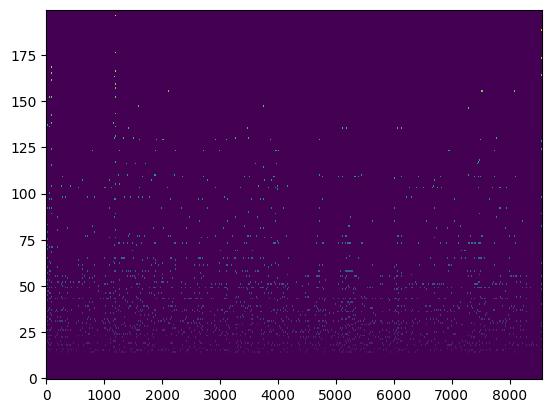

In [10]:
plt.imshow(pitches[0:200, :], aspect="auto", interpolation="nearest", origin="lower")

In [96]:
note_dictionary

{0: [('F♯3', np.float32(0.00015010416)),
  ('A3', np.float32(0.0001804981)),
  ('C4', np.float32(5.1506548e-05)),
  ('D♯4', np.float32(7.170868e-05)),
  ('F4', np.float32(8.302223e-05)),
  ('F♯4', np.float32(8.346299e-05)),
  ('G♯4', np.float32(4.6811318e-05)),
  ('A♯4', np.float32(0.000105842606)),
  ('B4', np.float32(0.00013000901)),
  ('D5', np.float32(0.00021830827)),
  ('D♯5', np.float32(0.00018318769)),
  ('E5', np.float32(0.00010965463)),
  ('F♯5', np.float32(0.00021836802)),
  ('G5', np.float32(5.480638e-05)),
  ('G♯5', np.float32(7.926501e-05)),
  ('A♯5', np.float32(0.00013613798)),
  ('B5', np.float32(7.0241316e-05)),
  ('B5', np.float32(0.00016663244)),
  ('C6', np.float32(0.00011999102)),
  ('C♯6', np.float32(0.00024144822)),
  ('D6', np.float32(0.00011823562)),
  ('D♯6', np.float32(0.00028692436)),
  ('E6', np.float32(0.00013435684)),
  ('F6', np.float32(8.4766965e-05)),
  ('F♯6', np.float32(0.000119684664)),
  ('F♯6', np.float32(8.70726e-05)),
  ('G6', np.float32(7.756241

In [97]:
librosa.key_to_notes()

TypeError: key_to_notes() missing 1 required positional argument: 'key'